# Self-Play in AI: From Board Games to Language Models

## What We'll Build

In this notebook, we'll implement a **complete self-play loop** from scratch using a language model. Self-play is a technique where a model learns by generating its own training data, evaluating its outputs, and fine-tuning on successful examples. This is the foundation behind techniques like AlphaZero (for games) and recent advances in language model reasoning (like STaR, ReST, and process reward models).

We'll use the **GSM8K dataset** (math word problems) as our playground. The model will:
1. Generate multiple solution attempts per problem
2. Verify which solutions are correct
3. Keep only the correct ones and fine-tune on them
4. Repeat to observe how the model's behavior changes

### What You'll Learn

This notebook demonstrates both **when self-play works** and **when it doesn't**. Qwen2.5-3B-Instruct already achieves ~86% accuracy on GSM8K, which means self-play has little room to improve — the model is already near its ceiling on this task. Instead of showing an artificial success, we'll see the **ceiling effect** in action: fine-tuning on the model's own correct solutions narrows its strategy diversity and causes accuracy to *decrease*. This is a critical lesson for practitioners — self-play is powerful when there's headroom, but counterproductive when the model is already strong.

For a clean demonstration of self-play actually improving performance, see **Notebook 00** (toy example with a weak learner on a simple task).

### Prerequisites
- Machine with GPU (T4 or better)
- Patience: we're learning, not racing
- ~90 minutes runtime (with 8 GPUs; longer with fewer)

### Model & Resources
- Model: **Qwen2.5-3B-Instruct** (instruction-tuned, strong math baseline, fits in 4-bit)
- Quantization: 4-bit (bitsandbytes) to fit in 16GB VRAM
- Efficient fine-tuning: LoRA (Low-Rank Adaptation)
- Data: GSM8K subset (200 train, 100 eval problems)
- Multi-GPU: parallel generation via `torch.multiprocessing` (8× speedup)

Let's begin!

## Setup & Installation

We support both **`uv`** (recommended, faster) and **`pip`** (Colab default). The cell below auto-detects which is available and uses the best option.

In [1]:
import shutil
import subprocess
import sys

# Auto-detect installer: prefer uv, fall back to pip
UV_AVAILABLE = shutil.which("uv") is not None

if UV_AVAILABLE:
    print("Using uv (detected on PATH)")

    def install_package(package):
        subprocess.check_call(["uv", "pip", "install", "-q", package])
else:
    print(
        "Using pip (uv not found — install uv for faster setup: https://docs.astral.sh/uv/)"
    )

    def install_package(package):
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])


print("Installing dependencies...\n")

packages = [
    "torch",
    "transformers>=4.40.0",
    "datasets",
    "accelerate",
    "bitsandbytes",
    "peft",
    "trl>=0.8.0",
    "numpy",
    "matplotlib",
    "scikit-learn",
]

for pkg in packages:
    try:
        install_package(pkg)
    except Exception as e:
        print(f"Warning: Could not install {pkg}: {e}")

print("\n✓ All dependencies installed!")

Using uv (detected on PATH)
Installing dependencies...


✓ All dependencies installed!


## Concept: What is Self-Play?

### The Idea

**Self-play** is a learning paradigm where an agent improves by playing against itself or learning from its own generated data. Here's the core loop:

```
Agent v1 → Generate outputs → Evaluate/Filter → Keep good ones
                                                        ↓
                                              Fine-tune on good outputs
                                                        ↓
                                            Agent v2 (improved)
```

### Historical Examples

1. **AlphaZero** (chess, Go, shogi): Trained by playing millions of games against itself. No human knowledge needed—just the rules of the game and self-play.

2. **AlphaFold**: Uses iterative refinement where predicted structures are scored and the model learns to improve them.

3. **Language Models**: Recent work (e.g., OpenAI's "Let's Verify Step by Step", Deepseek's reasoning models) uses self-play:
   - Generate multiple reasoning paths
   - Keep ones that reach correct answers
   - Fine-tune on successful trajectories
   - Repeat

### Why It Works

- **Emergent Curriculum**: Easy problems are solved early; failures concentrate on hard problems. The model automatically focuses on its own weaknesses.
- **Data Efficiency**: Instead of needing human labels for every example, we leverage the model's own correctness checks.
- **Scaling**: More compute + more self-play iterations ≈ stronger models.

### The Challenge

You need a **verifier**: a way to judge whether a generated output is correct. For math (GSM8K), we can extract the numeric answer and check it. For other domains (code, essays), verification is harder.

In this notebook, we'll focus on math where verification is straightforward.

## Loading Model & Tokenizer

We load **Qwen2.5-3B-Instruct** with 4-bit quantization (bitsandbytes). 4-bit means each weight is stored as 4 bits instead of 32 -- an ~8x memory reduction with minimal quality loss.

**Why the Instruct model?** Self-play requires the model to reliably attempt problem-solving and produce parseable answers (ending with `#### <number>`). Base models complete text but don't follow instructions — they generate correct answers only by luck, yielding <1% correctness with sampling (temperature > 0). The instruct model follows the prompt, solves step-by-step, and formats answers consistently, giving self-play enough signal to learn from.

**Multi-GPU support:** If multiple GPUs are detected, generation steps use `torch.multiprocessing` to spawn one worker process per GPU. Each process loads its own model replica and generates independently -- this **bypasses the Python GIL**, achieving true parallelism.

> **Why not threads?** Python's GIL serializes `model.generate()` across threads because the autoregressive loop alternates between Python code and CUDA kernels. Only separate *processes* can run truly in parallel.

> **Why not DDP?** `DistributedDataParallel` is designed for *training* (gradient synchronization), not inference. We use `torch.multiprocessing` for generation and single-GPU LoRA for fine-tuning (fast enough at 3B). DDP becomes essential when scaling training to larger models -- covered in our Large-Scale Engineering topic.

The main process loads one model for baseline evaluation and fine-tuning. Multi-GPU generation is handled by the worker module (`src/mp_generate.py`).

In [2]:
import sys
import time
from pathlib import Path

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# =====================================================================
# GPU Detection
# =====================================================================
NUM_GPUS = torch.cuda.device_count()
print(f"GPUs available: {NUM_GPUS}")
for i in range(NUM_GPUS):
    name = torch.cuda.get_device_name(i)
    mem_gb = torch.cuda.get_device_properties(i).total_memory / 1e9
    print(f"  GPU {i}: {name} ({mem_gb:.1f} GB)")

MULTI_GPU = NUM_GPUS > 1
if MULTI_GPU:
    print(f"\n-> Multi-GPU mode: generation will spawn {NUM_GPUS} worker processes")
    print(f"  (Each process loads its own model -- true parallelism, no GIL)")
else:
    print("\n-> Single-GPU mode")

# =====================================================================
# Import parallel generation (multi-GPU worker module)
# =====================================================================
# Add repo root to path so we can import src.mp_generate
repo_root = str(Path(".").resolve().parent.parent)  # notebooks/2026-W10 -> repo root
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

if MULTI_GPU:
    from src.mp_generate import parallel_generate

    print("Imported parallel_generate (torch.multiprocessing)")

# =====================================================================
# Load single model (for baseline eval + fine-tuning on GPU 0)
# =====================================================================
model_name = "Qwen/Qwen2.5-3B-Instruct"
print(f"\nLoading model on GPU 0: {model_name}")
start = time.time()

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map={"": 0},
    dtype=torch.float16,
    trust_remote_code=True,
)

elapsed = time.time() - start
print(f"Model loaded in {elapsed:.1f}s")
print(
    f"  Parameters: ~3B | Context:"
    f" {model.config.max_position_embeddings} | Vocab:"
    f" {tokenizer.vocab_size}"
)

# LoRA checkpoint path (used to pass fine-tuned weights to worker processes)
LORA_CKPT_DIR = "./lora_active_checkpoint"
lora_path = None  # Will be set after first fine-tuning iteration


GPUs available: 8
  GPU 0: NVIDIA H100 80GB HBM3 (85.3 GB)
  GPU 1: NVIDIA H100 80GB HBM3 (85.3 GB)
  GPU 2: NVIDIA H100 80GB HBM3 (85.3 GB)
  GPU 3: NVIDIA H100 80GB HBM3 (85.3 GB)
  GPU 4: NVIDIA H100 80GB HBM3 (85.3 GB)
  GPU 5: NVIDIA H100 80GB HBM3 (85.3 GB)
  GPU 6: NVIDIA H100 80GB HBM3 (85.3 GB)
  GPU 7: NVIDIA H100 80GB HBM3 (85.3 GB)

-> Multi-GPU mode: generation will spawn 8 worker processes
  (Each process loads its own model -- true parallelism, no GIL)
Imported parallel_generate (torch.multiprocessing)

Loading model on GPU 0: Qwen/Qwen2.5-3B-Instruct


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Model loaded in 9.8s
  Parameters: ~3B | Context: 32768 | Vocab: 151643


## GPU Diagnostic

Verify that the model is loaded on GPU 0 and all GPUs are visible. In multi-GPU mode, the generation step will spawn separate processes (one per GPU) -- you'll see all GPUs light up during the generation cells, not here.

In [3]:
# =====================================================================
# GPU Diagnostic: verify model placement and GPU visibility
# =====================================================================
print("Model Placement:")
print("-" * 50)
first_param = next(model.parameters())
print(f"  Model device: {first_param.device}")
print(f"  GPU 0 allocated: {torch.cuda.memory_allocated(0) / 1e6:.0f} MB")

print(f"\nAll GPUs visible: {NUM_GPUS}")
for i in range(NUM_GPUS):
    alloc = torch.cuda.memory_allocated(i) / 1e6
    print(f"  GPU {i}: {alloc:.0f} MB allocated")

if MULTI_GPU:
    print(
        f"\n-> Generation will use parallel_generate() with {NUM_GPUS} worker processes"
    )
    print(f"  Each worker loads its own model -- watch nvidia-smi during generation!")
else:
    print(f"\n-> Single-GPU: all operations on GPU 0")

# Quick sanity check
test_input = tokenizer("2 + 2 =", return_tensors="pt").to(model.device)
with torch.no_grad():
    out = model.generate(**test_input, max_new_tokens=5, do_sample=False)
decoded = tokenizer.decode(
    out[0][test_input["input_ids"].shape[1] :],
    skip_special_tokens=True,
).strip()
print(f"\nSanity check: '2 + 2 = {decoded}'")
print("Model ready")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Model Placement:
--------------------------------------------------
  Model device: cuda:0
  GPU 0 allocated: 2073 MB

All GPUs visible: 8
  GPU 0: 2073 MB allocated
  GPU 1: 0 MB allocated
  GPU 2: 0 MB allocated
  GPU 3: 0 MB allocated
  GPU 4: 0 MB allocated
  GPU 5: 0 MB allocated
  GPU 6: 0 MB allocated
  GPU 7: 0 MB allocated

-> Generation will use parallel_generate() with 8 worker processes
  Each worker loads its own model -- watch nvidia-smi during generation!

Sanity check: '2 + 2 = 10
\'
Model ready


## Loading the Dataset

We'll use **GSM8K** (Grade School Math 8K)—a dataset of ~8,500 grade school math word problems with solutions. We'll take a subset:
- **200 examples for training/self-play**
- **100 examples for evaluation**

This keeps training fast (~15-20 min) while being representative enough to see improvement.

In [4]:
import random

from datasets import load_dataset

print("Loading GSM8K dataset...")
dataset = load_dataset("openai/gsm8k", "main", trust_remote_code=True)

# Extract train and test
train_data = dataset["train"]
test_data = dataset["test"]

print(f"Full dataset: {len(train_data)} train, {len(test_data)} test")

# Create subsets for faster iteration
random.seed(42)
train_indices = random.sample(range(len(train_data)), min(200, len(train_data)))
eval_indices = random.sample(range(len(test_data)), min(100, len(test_data)))

train_subset = [train_data[i] for i in train_indices]
eval_subset = [test_data[i] for i in eval_indices]

print(f"\nUsing subsets: {len(train_subset)} train, {len(eval_subset)} eval")

# Show an example
example = train_subset[0]
print(f"\nExample problem:")
print(f"Question: {example['question']}")
print(f"\nFull solution:\n{example['answer']}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'openai/gsm8k' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading GSM8K dataset...
Full dataset: 7473 train, 1319 test

Using subsets: 200 train, 100 eval

Example problem:
Question: For every 12 cans you recycle, you receive $0.50, and for every 5 kilograms of newspapers, you receive $1.50. If your family collected 144 cans and 20 kilograms of newspapers, how much money would you receive?

Full solution:
There are 144/12 = <<144/12=12>>12 sets of 12 cans that the family collected.
So, the family would receive $0.50 x 12 = $<<0.50*12=6>>6 for the cans.
There are 20/5 = <<20/5=4>>4 sets of 5 kilograms of newspapers that the family collected.
So, the family would receive $1.50 x 4 = $<<1.50*4=6>>6 for the newspapers.
Therefore, the family would receive a total of $6 + $6 = $<<6+6=12>>12.
#### 12


## Step 0: Extract Ground Truth Answers

GSM8K solutions are formatted as:
```
Step 1: ...
Step 2: ...
...
#### <numeric_answer>
```

We need to extract the numeric answer (after `####`) so we can compare generated solutions against ground truth.

In [5]:
import re


def extract_answer(solution_text):
    """
    Extract numeric answer from GSM8K solution.
    GSM8K format: solution ends with #### <number>
    """
    # Look for pattern: #### <number>
    match = re.search(r"####\s*([\d.\-]+)", solution_text)
    if match:
        try:
            # Try to parse as float, then int if no decimal
            answer_str = match.group(1)
            if "." in answer_str:
                return float(answer_str)
            else:
                return int(answer_str)
        except:
            return None
    return None


def answers_match(generated, ground_truth, tolerance=1e-3):
    """
    Compare two answers with numerical tolerance.
    """
    if generated is None or ground_truth is None:
        return False

    try:
        return abs(float(generated) - float(ground_truth)) < tolerance
    except:
        return False


# Pre-extract all ground truth answers
ground_truth_answers = {}
for idx, example in enumerate(train_subset):
    answer = extract_answer(example["answer"])
    ground_truth_answers[idx] = answer

eval_ground_truth_answers = {}
for idx, example in enumerate(eval_subset):
    answer = extract_answer(example["answer"])
    eval_ground_truth_answers[idx] = answer

print(f"Extracted {len(ground_truth_answers)} ground truth answers for training set")
print(f"Extracted {len(eval_ground_truth_answers)} ground truth answers for eval set")

# Verify extraction worked
sample_idx = 0
print(f"\nSample extraction:")
print(f"Ground truth answer: {ground_truth_answers[sample_idx]}")
print(f"Full solution end: ...{train_subset[sample_idx]['answer'][-100:]}")

Extracted 200 ground truth answers for training set
Extracted 100 ground truth answers for eval set

Sample extraction:
Ground truth answer: 12
Full solution end: ... for the newspapers.
Therefore, the family would receive a total of $6 + $6 = $<<6+6=12>>12.
#### 12


## Baseline Evaluation

Before self-play, let's measure how well the **untrained model** performs on our eval set. We'll:
1. Generate one solution per problem (greedy decoding, temperature=0)
2. Extract the numeric answer
3. Compare to ground truth
4. Compute accuracy

**Why this matters:** The baseline establishes the "headroom" available for self-play. If the model is already very accurate, self-play has limited room to improve — and may actually cause degradation (we'll see this happen). If the baseline is low (say 20-40%), there's plenty of room and self-play can drive significant improvement.

In [6]:
# =====================================================================
# Chat template formatting — critical for instruct models!
#
# Instruct models (like Qwen2.5-3B-Instruct) are fine-tuned with a
# specific chat template (ChatML: <|im_start|>/<|im_end|> tokens).
# If you feed them raw text like "Question:\n...\nSolution:\n", they
# don't recognize it as an instruction and produce incoherent output.
#
# We use tokenizer.apply_chat_template() so the prompt is automatically
# formatted in whatever template the model expects. This makes the code
# model-agnostic — swap in any instruct model and it just works.
#
# The system prompt explicitly asks for "#### <number>" format so the
# model's output matches our extract_answer() regex.
# =====================================================================

SYSTEM_PROMPT = (
    "You are a math problem solver. Solve the problem step by step, "
    "showing your reasoning. End your solution with #### followed by "
    "the final numeric answer (e.g., #### 42)."
)


def format_prompt(question, tokenizer):
    """Format a question using the model's chat template for generation."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


def format_training_example(question, solution, tokenizer):
    """Format a complete training example (question + solution) using chat template.

    This produces the full conversation including the assistant's response,
    which is what SFTTrainer needs for supervised fine-tuning.
    """
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
        {"role": "assistant", "content": solution},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )


def generate_solution(
    problem,
    model,
    tokenizer,
    max_tokens=512,
    temperature=0.7,
    num_return_sequences=1,
):
    """
    Generate one or more solutions for a math problem (single GPU, main process).
    Used for baseline evaluation and single-problem generation.
    """
    prompt = format_prompt(problem, tokenizer)
    inputs = tokenizer(prompt, return_tensors="pt", padding=False).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_tokens,
            temperature=temperature,
            top_p=0.95,
            num_return_sequences=num_return_sequences,
            do_sample=(temperature > 0),
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    # Strip prompt using token length (not character length).
    # Character-level stripping breaks when chat templates add special tokens
    # that are removed by skip_special_tokens=True, causing offset mismatch.
    prompt_len = inputs["input_ids"].shape[1]
    solutions = []
    for output in outputs:
        text = tokenizer.decode(output[prompt_len:], skip_special_tokens=True)
        solutions.append(text)
    return solutions


def generate_solutions_batch(
    problems, model, tokenizer, K=4, temperature=0.7, lora_path=None
):
    """
    Generate K solutions per problem.

    - Single GPU: sequential loop using the main-process model.
    - Multi-GPU: delegates to parallel_generate() which spawns one process
      per GPU via torch.multiprocessing. Each process loads its own model,
      generates independently, and writes results to disk. This bypasses the
      GIL entirely for true N-GPU parallelism.
    """
    if MULTI_GPU:
        return parallel_generate(
            model_name=model_name,
            problems=problems,
            num_gpus=NUM_GPUS,
            K=K,
            temperature=temperature,
            max_tokens=512,
            lora_path=lora_path,
        )
    else:
        all_solutions = {}
        for idx, example in enumerate(problems):
            solutions = generate_solution(
                example["question"],
                model,
                tokenizer,
                num_return_sequences=K,
                temperature=temperature,
            )
            all_solutions[idx] = solutions
            if (idx + 1) % 10 == 0:
                print(f"  Generated {idx + 1}/{len(problems)} problems")
        return all_solutions


# Quick sanity check: show what the formatted prompt looks like
sample_prompt = format_prompt("What is 2 + 3?", tokenizer)
print("Sample formatted prompt:")
print(repr(sample_prompt[:200]))
print(f"\n(Total prompt length: {len(sample_prompt)} chars)")

# =====================================================================
# Baseline Evaluation — measure accuracy BEFORE any fine-tuning
# =====================================================================
print("\n" + "=" * 60)
print("BASELINE EVALUATION")
print("=" * 60)

model.eval()  # Ensure eval mode for generation
correct = 0
total = len(eval_subset)
start_eval = time.time()

for idx, example in enumerate(eval_subset):
    if (idx + 1) % 20 == 0:
        elapsed = time.time() - start_eval
        print(f"  Progress: {idx + 1}/{total} ({elapsed:.1f}s)")

    question = example["question"]
    solutions = generate_solution(question, model, tokenizer, temperature=0.0)
    generated_answer = extract_answer(solutions[0])
    ground_truth = eval_ground_truth_answers[idx]

    if answers_match(generated_answer, ground_truth):
        correct += 1

eval_time = time.time() - start_eval
baseline_accuracy = correct / total

print(f"\n{'=' * 50}")
print(f"BASELINE ACCURACY: {correct}/{total} = {baseline_accuracy * 100:.1f}%")
print(f"{'=' * 50}")


Sample formatted prompt:
'<|im_start|>system\nYou are a math problem solver. Solve the problem step by step, showing your reasoning. End your solution with #### followed by the final numeric answer (e.g., #### 42).<|im_end|>\n<|'

(Total prompt length: 262 chars)

BASELINE EVALUATION
  Progress: 20/100 (173.6s)
  Progress: 40/100 (409.0s)
  Progress: 60/100 (602.9s)
  Progress: 80/100 (827.7s)
  Progress: 100/100 (1019.4s)

BASELINE ACCURACY: 86/100 = 86.0%


## Concept: The Self-Play Loop

Now we'll run the core self-play algorithm. Each iteration:

### 1. **Generate**: Sample K solutions per training problem
   - Use temperature > 0 for diversity
   - K=4 per problem is a good balance (not too slow, enough diversity)

### 2. **Verify & Filter**: Check which solutions are correct
   - Extract answer from each solution
   - Compare to ground truth
   - Keep only correct solutions

### 3. **Fine-tune**: Update model weights on correct solutions
   - Use supervised fine-tuning (SFT) with LoRA
   - LoRA keeps model compact (only ~3% parameters trainable)
   - Low learning rate (2e-5) to avoid catastrophic forgetting

### 4. **Evaluate**: Test on eval set to measure progress

### Why This Works

- **Emergent curriculum**: As the model improves, it naturally tackles harder problems. Easy problems are solved first and contribute less to fine-tuning.
- **Positive reinforcement**: We only train on correct examples, so the model learns what works.
- **Scaling**: More iterations = more improvement (with diminishing returns).

### Limitations

- **Verification bottleneck**: For complex tasks (essays, code), verification is hard. Self-play works best when ground truth is clear.
- **Plateau**: Eventually, the model generates the same solutions repeatedly and hits a ceiling.
- **Data quality**: Generating many wrong solutions early on means less training data. This improves with model strength.

## Step 1: Generate Multiple Solutions

For each training problem, we'll generate K=4 solutions with temperature=0.7 (diverse but reasonable). This takes a few minutes.

In [7]:
print("SELF-PLAY ITERATION 1")
print("=" * 60)
print(f"\nStep 1: Generating {len(train_subset)} problems x 4 solutions...")
if MULTI_GPU:
    print(f"  (Spawning {NUM_GPUS} worker processes -- watch nvidia-smi!)")
start_gen = time.time()

generated_solutions = generate_solutions_batch(
    train_subset, model, tokenizer, K=4, temperature=0.7, lora_path=lora_path
)

gen_time = time.time() - start_gen
print(f"\nGeneration complete ({gen_time:.1f}s)")
print(f"  Total generated: {len(generated_solutions) * 4} solutions")

SELF-PLAY ITERATION 1

Step 1: Generating 200 problems x 4 solutions...
  (Spawning 8 worker processes -- watch nvidia-smi!)
  Distributing 200 problems across 8 GPUs (25, 25, 25, 25, 25, 25, 25, 25 each)


Loading weights: 100%|██████████| 434/434 [00:02<00:00, 211.33it/s]


  [GPU 5] 10/25 problems done
  [GPU 5] 20/25 problems done
  [GPU 5] 25/25 problems done
  [GPU 7] 10/25 problems done
  [GPU 7] 20/25 problems done
  [GPU 7] 25/25 problems done
  [GPU 4] 10/25 problems done
  [GPU 4] 20/25 problems done
  [GPU 4] 25/25 problems done
  [GPU 3] 10/25 problems done
  [GPU 3] 20/25 problems done
  [GPU 3] 25/25 problems done
  [GPU 2] 10/25 problems done
  [GPU 2] 20/25 problems done
  [GPU 2] 25/25 problems done
  [GPU 0] 10/25 problems done
  [GPU 0] 20/25 problems done
  [GPU 0] 25/25 problems done
  [GPU 1] 10/25 problems done
  [GPU 1] 20/25 problems done
  [GPU 1] 25/25 problems done
  [GPU 6] 10/25 problems done
  [GPU 6] 20/25 problems done
  [GPU 6] 25/25 problems done
  ✓ Collected results for 200 problems

Generation complete (1330.8s)
  Total generated: 800 solutions


## Step 2: Verify & Filter Correct Solutions

Extract answers from generated solutions and keep only the correct ones. We'll track statistics to see how many solutions are correct (this improves over iterations).

In [8]:
def filter_correct_solutions(generated_dict, ground_truth_dict):
    """
    Filter solutions to keep only correct ones.

    Returns:
        (correct_solutions_list, stats_dict)
    """
    correct_solutions = []
    total_generated = 0
    total_correct = 0
    correct_by_problem = {}  # Track how many correct per problem

    for problem_idx, solutions_list in generated_dict.items():
        ground_truth = ground_truth_dict[problem_idx]

        for solution in solutions_list:
            total_generated += 1
            generated_answer = extract_answer(solution)

            if answers_match(generated_answer, ground_truth):
                total_correct += 1
                correct_solutions.append(
                    {
                        "problem_idx": problem_idx,
                        "solution": solution,
                        "question": None,  # Will be filled in later
                    }
                )

        correct_by_problem[problem_idx] = sum(
            1
            for sol in solutions_list
            if answers_match(extract_answer(sol), ground_truth)
        )

    stats = {
        "total_generated": total_generated,
        "total_correct": total_correct,
        "accuracy": total_correct / total_generated if total_generated > 0 else 0,
        "correct_by_problem": correct_by_problem,
    }

    return correct_solutions, stats


print("Step 2: Verifying and filtering solutions...")
start_verify = time.time()

correct_solutions, stats = filter_correct_solutions(
    generated_solutions, ground_truth_answers
)

verify_time = time.time() - start_verify

# Add question to each correct solution
for sol_dict in correct_solutions:
    sol_dict["question"] = train_subset[sol_dict["problem_idx"]]["question"]

print(f"\n✓ Verification complete ({verify_time:.1f}s)")
print(f"\n{'=' * 60}")
print(f"Filtering Results (Iteration 1):")
print(f"  Generated: {stats['total_generated']} solutions")
print(f"  Correct: {stats['total_correct']} solutions")
print(f"  Correctness Rate: {stats['accuracy'] * 100:.1f}%")
print(
    f"  Problems with ≥1 correct solution: {sum(1 for c in stats['correct_by_problem'].values() if c > 0)}/{len(stats['correct_by_problem'])}"
)
print(f"{'=' * 60}")

Step 2: Verifying and filtering solutions...

✓ Verification complete (0.0s)

Filtering Results (Iteration 1):
  Generated: 800 solutions
  Correct: 678 solutions
  Correctness Rate: 84.8%
  Problems with ≥1 correct solution: 187/200


## Step 3: Fine-tune on Correct Solutions

We'll use **LoRA** (Low-Rank Adaptation) + **SFTTrainer** from the `trl` library to fine-tune efficiently on the correct solutions. LoRA only trains ~3% of parameters, keeping memory usage low.

In [9]:
from pathlib import Path

from peft import LoraConfig, get_peft_model
from trl import SFTConfig, SFTTrainer


def prepare_training_data(correct_solutions):
    """Format correct solutions as a HF Dataset for SFTTrainer.

    Uses format_training_example() (defined in cell 13) to wrap each
    question+solution pair in the model's chat template. This ensures
    training data format exactly matches what the model sees during
    generation — critical for instruct models that expect ChatML tokens.
    """
    from datasets import Dataset

    texts = []
    for item in correct_solutions:
        text = format_training_example(item["question"], item["solution"], tokenizer)
        texts.append(text)
    return Dataset.from_dict({"text": texts})


def setup_lora(model):
    """Setup LoRA for efficient fine-tuning (rank=16, alpha=32).

    Strips any existing LoRA adapter first (using unload(), not
    merge_and_unload) and cleans up residual PEFT config attributes
    to prevent "modifying model a second time" warnings.
    """
    from peft import PeftModel

    if isinstance(model, PeftModel):
        model = model.unload()

    # Clean residual PEFT attributes left after unload() — without this,
    # get_peft_model sees stale peft_config and warns about double-wrapping.
    # Use try/except because some attrs are properties on the base model
    # class that hasattr() detects but delattr() can't remove.
    for attr in ("peft_config", "active_adapter", "active_adapters"):
        try:
            delattr(model, attr)
        except (AttributeError, TypeError):
            pass

    # Enable gradient computation for non-frozen params
    for param in model.parameters():
        param.requires_grad = False
    model.enable_input_require_grads()

    lora_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=["q_proj", "v_proj"],
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
    )
    model = get_peft_model(model, lora_config)
    return model


def fine_tune_iteration(model, tokenizer, training_texts, iteration_num):
    """
    Fine-tune model with LoRA on GPU 0, then save adapter for worker processes.

    Why single-GPU training? Two reasons:
    1. bitsandbytes 4-bit layers don't survive DataParallel/DDP replication.
       The NF4 quantization state is tied to a specific device; copying the
       module to other GPUs loses that state and crashes with
       cudaErrorIllegalAddress when LoRA layers run on replicated copies.
    2. Training is fast anyway (~30s for <200 examples, 1 epoch). The real
       bottleneck is generation (solved by multi-GPU mp.spawn). Spending
       engineering effort on distributed training for a 30s step would be
       premature optimization.

    See the FSDP tutorial for proper distributed training of quantized models.
    """
    model = setup_lora(model)
    model.print_trainable_parameters()

    # Save LoRA adapter path for multi-GPU workers
    lora_save_dir = f"lora_iter_{iteration_num}"

    # Note on trl API (v0.14+):
    #   - max_seq_length is now max_length
    #   - dataset_text_field stays in SFTConfig
    #   - packing=False prevents concatenating examples
    #   - SFTTrainer takes processing_class= instead of tokenizer=
    #   - Use bf16 (not fp16) on Ampere+ GPUs: fp16 enables GradScaler
    #     which doesn't support BFloat16 tensors from paged_adamw_8bit
    config = SFTConfig(
        output_dir=f"./sft_output_iter_{iteration_num}",
        num_train_epochs=1,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=2,
        learning_rate=2e-4,
        logging_steps=5,
        save_strategy="no",
        bf16=torch.cuda.is_available() and torch.cuda.is_bf16_supported(),
        optim="paged_adamw_8bit",
        report_to="none",
        dataset_text_field="text",
        max_length=512,
        packing=False,
    )

    # =====================================================================
    # CRITICAL: Prevent DataParallel wrapping during BOTH init AND train().
    #
    # Newer transformers/accelerate check device_count at train time, not
    # just at __init__. If we restore early, Trainer wraps the 4-bit model
    # in DataParallel → replicates NF4 layers to other GPUs → CUDA illegal
    # memory access (cudaErrorIllegalAddress) at the LoRA forward pass.
    #
    # The patch must stay active through the entire trainer.train() call.
    # =====================================================================
    _real_device_count = torch.cuda.device_count
    torch.cuda.device_count = lambda: 1

    try:
        trainer = SFTTrainer(
            model=model,
            processing_class=tokenizer,
            train_dataset=training_texts,
            args=config,
        )

        start_time = __import__("time").time()
        trainer.train()
        train_time = __import__("time").time() - start_time
    finally:
        # Always restore, even if training crashes
        torch.cuda.device_count = _real_device_count

    # IMPORTANT: Switch back to eval mode after training.
    # SFTTrainer leaves the model in training mode, which keeps
    # lora_dropout active (5% of LoRA activations randomly zeroed).
    # This corrupts generation output and causes 0% eval accuracy.
    model.eval()

    print(f"\n✓ Fine-tuning complete ({train_time:.1f}s)")

    # Save LoRA adapter so multi-GPU workers can load base + adapter
    model.save_pretrained(lora_save_dir)
    print(f"  LoRA adapter saved to {lora_save_dir}/")

    return model, train_time


print("Step 3: Fine-tuning...")

# Check if we have enough data
if len(correct_solutions) < 2:
    print(f"WARNING: Only {len(correct_solutions)} correct solutions found.")
    print("Skipping fine-tuning — need more data for meaningful training.")
    print("Consider: lower temperature, more K samples, or a stronger base model.")
    train_time = 0.0
    lora_path = None
else:
    training_texts = prepare_training_data(correct_solutions)
    print(f"Training on {len(training_texts)} correct solutions")

    model, train_time = fine_tune_iteration(
        model, tokenizer, training_texts, iteration_num=1
    )
    lora_path = "lora_iter_1"

Step 3: Fine-tuning...
Training on 678 correct solutions
trainable params: 3,686,400 || all params: 3,089,625,088 || trainable%: 0.1193


Adding EOS to train dataset:   0%|          | 0/678 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/678 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/678 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
5,7.283322
10,4.945891
15,3.995620
20,3.240714



✓ Fine-tuning complete (22.6s)
  LoRA adapter saved to lora_iter_1/


## Step 4: Evaluate After Fine-tuning

Test the fine-tuned model on the evaluation set and compare accuracy to baseline.

In [10]:
def evaluate_model(model, tokenizer, eval_subset, eval_ground_truth, iteration_num):
    """
    Evaluate model accuracy on eval set.
    """
    print(f"\nStep 4: Evaluating after iteration {iteration_num}...")

    correct = 0
    total = len(eval_subset)
    start_eval = time.time()

    for idx, example in enumerate(eval_subset):
        if (idx + 1) % 20 == 0:
            elapsed = time.time() - start_eval
            print(f"  Progress: {idx + 1}/{total} ({elapsed:.1f}s)")

        question = example["question"]

        # Generate solution (greedy)
        solutions = generate_solution(question, model, tokenizer, temperature=0.0)
        generated_answer = extract_answer(solutions[0])
        ground_truth = eval_ground_truth[idx]

        if answers_match(generated_answer, ground_truth):
            correct += 1

    eval_time = time.time() - start_eval
    accuracy = correct / total

    print(f"✓ Evaluation complete ({eval_time:.1f}s)")

    return accuracy, correct, eval_time


# Evaluate iteration 1
iter1_accuracy, iter1_correct, eval_time = evaluate_model(
    model, tokenizer, eval_subset, eval_ground_truth_answers, iteration_num=1
)

print(f"\n{'=' * 60}")
print(f"ITERATION 1 RESULTS:")
print(f"  Accuracy: {iter1_correct}/{len(eval_subset)} = {iter1_accuracy * 100:.1f}%")
print(f"  Improvement vs Baseline: {(iter1_accuracy - baseline_accuracy) * 100:+.1f}%")
print(f"{'=' * 60}")


Step 4: Evaluating after iteration 1...
  Progress: 20/100 (224.0s)
  Progress: 40/100 (509.0s)
  Progress: 60/100 (770.3s)
  Progress: 80/100 (1073.0s)
  Progress: 100/100 (1338.8s)
✓ Evaluation complete (1351.7s)

ITERATION 1 RESULTS:
  Accuracy: 80/100 = 80.0%
  Improvement vs Baseline: -6.0%


## Full Self-Play Loop: Multiple Iterations

Now let's wrap the entire self-play process (generate → verify → fine-tune → evaluate) into a loop and run 2 more iterations. We'll track accuracy progression.

In [11]:
# Store results for plotting
results = {
    "baseline": baseline_accuracy,
    "iterations": [iter1_accuracy],
    "correctness_rates": [stats["accuracy"]],
    "training_times": [train_time],
    "eval_times": [eval_time],
}

# Run iterations 2 and 3
for iteration in range(2, 4):
    print(f"\n\n{'=' * 60}")
    print(f"SELF-PLAY ITERATION {iteration}")
    print(f"{'=' * 60}")

    # Step 1: Generate (multi-GPU workers load base + LoRA adapter)
    print(f"\nStep 1: Generating {len(train_subset)} problems x 4 solutions...")
    if MULTI_GPU:
        print(f"  (Spawning {NUM_GPUS} workers, each loading base model + LoRA)")
    start_gen = time.time()
    generated_solutions = generate_solutions_batch(
        train_subset, model, tokenizer, K=4, temperature=0.7, lora_path=lora_path
    )
    gen_time = time.time() - start_gen
    print(f"Generation complete ({gen_time:.1f}s)")

    # Step 2: Verify & Filter
    print(f"\nStep 2: Verifying and filtering...")
    correct_solutions, stats = filter_correct_solutions(
        generated_solutions, ground_truth_answers
    )
    for sol_dict in correct_solutions:
        sol_dict["question"] = train_subset[sol_dict["problem_idx"]]["question"]

    print(
        f"  Correctness: {stats['total_correct']}/{stats['total_generated']} = {stats['accuracy'] * 100:.1f}%"
    )
    print(
        f"  Problems covered: {sum(1 for c in stats['correct_by_problem'].values() if c > 0)}/{len(stats['correct_by_problem'])}"
    )

    results["correctness_rates"].append(stats["accuracy"])

    # Step 3: Fine-tune on GPU 0, save LoRA for next round's workers
    training_texts = prepare_training_data(correct_solutions)
    model, train_time = fine_tune_iteration(
        model, tokenizer, training_texts, iteration_num=iteration
    )
    results["training_times"].append(train_time)

    # Step 4: Evaluate
    iter_accuracy, iter_correct, eval_time = evaluate_model(
        model,
        tokenizer,
        eval_subset,
        eval_ground_truth_answers,
        iteration_num=iteration,
    )
    results["iterations"].append(iter_accuracy)
    results["eval_times"].append(eval_time)

    print(f"\n{'=' * 60}")
    print(f"ITERATION {iteration} RESULTS:")
    print(f"  Accuracy: {iter_correct}/{len(eval_subset)} = {iter_accuracy * 100:.1f}%")
    print(
        f"  Change from Iteration {iteration - 1}: {(iter_accuracy - results['iterations'][iteration - 2]) * 100:+.1f}%"
    )
    print(f"  Change from Baseline: {(iter_accuracy - baseline_accuracy) * 100:+.1f}%")
    print(f"{'=' * 60}")

print(f"\n\nAll iterations complete!")



SELF-PLAY ITERATION 2

Step 1: Generating 200 problems x 4 solutions...
  (Spawning 8 workers, each loading base model + LoRA)
  Distributing 200 problems across 8 GPUs (25, 25, 25, 25, 25, 25, 25, 25 each)


Loading weights: 100%|██████████| 434/434 [00:02<00:00, 214.46it/s]


  [GPU 5] 10/25 problems done
  [GPU 5] 20/25 problems done
  [GPU 5] 25/25 problems done
  [GPU 2] 10/25 problems done
  [GPU 2] 20/25 problems done
  [GPU 2] 25/25 problems done
  [GPU 7] 10/25 problems done
  [GPU 7] 20/25 problems done
  [GPU 7] 25/25 problems done
  [GPU 0] 10/25 problems done
  [GPU 0] 20/25 problems done
  [GPU 0] 25/25 problems done
  [GPU 4] 10/25 problems done
  [GPU 4] 20/25 problems done
  [GPU 4] 25/25 problems done
  [GPU 3] 10/25 problems done
  [GPU 3] 20/25 problems done
  [GPU 3] 25/25 problems done
  [GPU 1] 10/25 problems done
  [GPU 1] 20/25 problems done
  [GPU 1] 25/25 problems done
  [GPU 6] 10/25 problems done
  [GPU 6] 20/25 problems done
  [GPU 6] 25/25 problems done
  ✓ Collected results for 200 problems
Generation complete (1472.0s)

Step 2: Verifying and filtering...
  Correctness: 632/800 = 79.0%
  Problems covered: 191/200
trainable params: 3,686,400 || all params: 3,089,625,088 || trainable%: 0.1193


Adding EOS to train dataset:   0%|          | 0/632 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/632 [00:00<?, ? examples/s]

...

Adding EOS to train dataset:   0%|          | 0/636 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/636 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/636 [00:00<?, ? examples/s]

Step,Training Loss
5,7.213322
10,5.057536
15,3.871106
20,3.245074



✓ Fine-tuning complete (20.8s)
  LoRA adapter saved to lora_iter_3/

Step 4: Evaluating after iteration 3...
  Progress: 20/100 (225.2s)
  Progress: 40/100 (494.8s)
  Progress: 60/100 (742.8s)
  Progress: 80/100 (1033.1s)
  Progress: 100/100 (1291.3s)
✓ Evaluation complete (1304.9s)

ITERATION 3 RESULTS:
  Accuracy: 70/100 = 70.0%
  Change from Iteration 2: +1.0%
  Change from Baseline: -16.0%


All iterations complete!


## Visualize Results

Let's plot how accuracy changes across the self-play loop. As we'll see, accuracy **decreased** rather than improved — this is the ceiling effect in action.

✓ Saved plot: self_play_progress.png


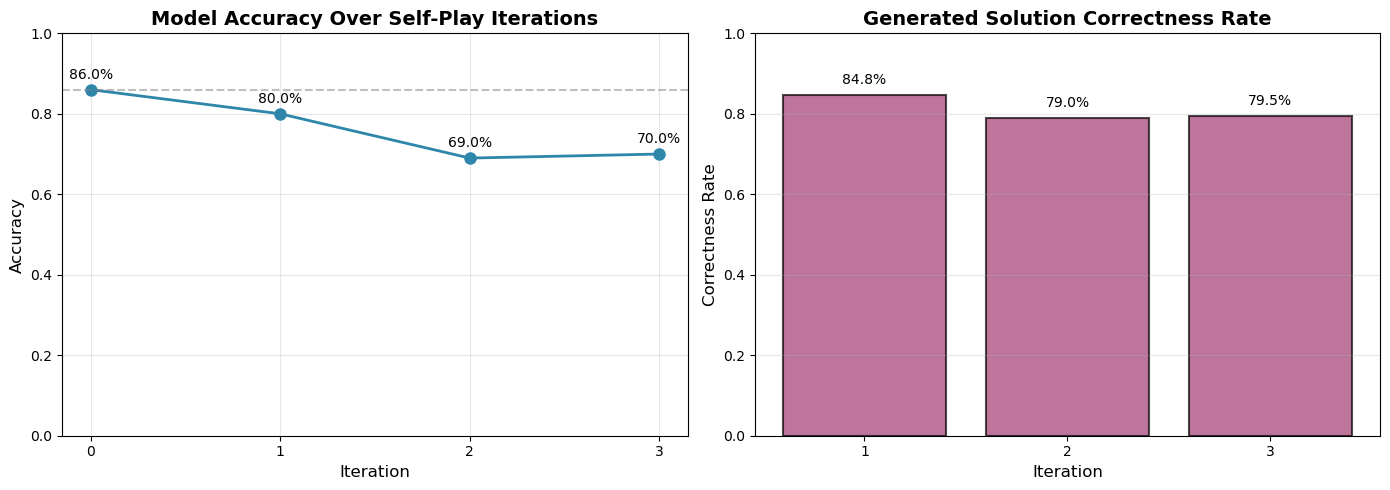


SELF-PLAY SUMMARY
Baseline accuracy: 86.0%
Final accuracy: 70.0%
Total improvement: -16.0%

Iteration-by-iteration improvement:
  Iter 1: 80.0% (Δ -6.0%)
  Iter 2: 69.0% (Δ -11.0%)
  Iter 3: 70.0% (Δ +1.0%)

Total training time across all iterations: 64.3s
Total eval time: 3977.5s


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
iterations = [0] + list(range(1, len(results["iterations"]) + 1))
accuracies = [results["baseline"]] + results["iterations"]
correctness_rates = [None] + results[
    "correctness_rates"
]  # First is None (baseline has no generation)

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Evaluation Accuracy
ax1.plot(
    iterations,
    accuracies,
    marker="o",
    linewidth=2,
    markersize=8,
    color="#2E86AB",
    label="Eval Accuracy",
)
ax1.axhline(
    y=results["baseline"],
    color="gray",
    linestyle="--",
    alpha=0.5,
    label="Baseline",
)
ax1.set_xlabel("Iteration", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12)
ax1.set_title(
    "Model Accuracy Over Self-Play Iterations",
    fontsize=14,
    fontweight="bold",
)
ax1.set_xticks(iterations)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# Add value labels on points
for i, acc in enumerate(accuracies):
    ax1.text(
        iterations[i],
        acc + 0.02,
        f"{acc * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

# Plot 2: Correctness Rate (% of generated solutions that are correct)
correctness_iterations = [i for i in range(1, len(results["correctness_rates"]) + 1)]
ax2.bar(
    correctness_iterations,
    results["correctness_rates"],
    color="#A23B72",
    alpha=0.7,
    edgecolor="black",
    linewidth=1.5,
)
ax2.set_xlabel("Iteration", fontsize=12)
ax2.set_ylabel("Correctness Rate", fontsize=12)
ax2.set_title("Generated Solution Correctness Rate", fontsize=14, fontweight="bold")
ax2.set_xticks(correctness_iterations)
ax2.grid(True, alpha=0.3, axis="y")
ax2.set_ylim([0, 1])

# Add value labels on bars
for i, rate in enumerate(results["correctness_rates"]):
    ax2.text(
        i + 1,
        rate + 0.02,
        f"{rate * 100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.savefig("self_play_progress.png", dpi=150, bbox_inches="tight")
print("✓ Saved plot: self_play_progress.png")
plt.show()

# Summary statistics
print(f"\n{'=' * 60}")
print("SELF-PLAY SUMMARY")
print(f"{'=' * 60}")
print(f"Baseline accuracy: {results['baseline'] * 100:.1f}%")
print(f"Final accuracy: {results['iterations'][-1] * 100:.1f}%")
print(
    f"Total improvement: {(results['iterations'][-1] - results['baseline']) * 100:+.1f}%"
)
print(f"\nIteration-by-iteration improvement:")
for i, acc in enumerate(results["iterations"], 1):
    prev = results["baseline"] if i == 1 else results["iterations"][i - 2]
    print(f"  Iter {i}: {acc * 100:.1f}% (Δ {(acc - prev) * 100:+.1f}%)")
print(
    f"\nTotal training time across all iterations: {sum(results['training_times']):.1f}s"
)
print(f"Total eval time: {sum(results['eval_times']):.1f}s")
print(f"{'=' * 60}")

## Analysis: What Happened and Why

### Our Results

| | Baseline | Iter 1 | Iter 2 | Iter 3 |
|---|---|---|---|---|
| **Eval Accuracy** | 86% | 80% | 69% | 70% |
| **Correctness Rate** | — | 84.8% | 79.0% | 79.5% |
| **Δ from Baseline** | — | -6% | -17% | -16% |

Self-play **decreased** accuracy by 16 percentage points. Why?

### The Ceiling Effect

Qwen2.5-3B-Instruct already achieves 86% on GSM8K — it's a strong math model. When we run self-play:

1. **Generation produces mostly correct solutions** (84.8% correctness rate). This means the model is training on examples it already knows how to solve. There's no new signal.

2. **Fine-tuning narrows strategy diversity.** The model converges toward a smaller set of solution patterns — the ones it happens to generate most often. This overfits to common strategies and loses ability to handle edge cases.

3. **The degradation compounds.** Each iteration, the model generates slightly less diverse solutions (correctness drops from 84.8% → 79.0%), fine-tunes on this narrower set, and gets slightly worse. By iteration 3 it stabilizes — the model has reached a new (lower) equilibrium.

### When Does Self-Play Actually Improve Performance?

Self-play works when there's **headroom** — a gap between what the model currently achieves and what it could achieve with better training data. Specifically:

- **Low baseline (20-40%)**: Plenty of room. The model generates a mix of correct and incorrect solutions. Fine-tuning on the correct ones teaches genuinely new patterns. This is the regime where STaR (Zelikman et al. 2022) and ReST (Gulcehre et al. 2023) report dramatic gains.

- **Medium baseline (40-70%)**: The sweet spot. Enough correct solutions for reliable training, but enough headroom that the model actually learns new strategies from its successes.

- **High baseline (>80%)**: Ceiling effect. The model is already strong. Fine-tuning on its own output doesn't add information — it reduces diversity and causes overfitting.

### How to Fix This

If you want self-play to improve a strong model:

1. **Use a harder dataset.** GSM8K is too easy for this model. MATH (competition-level), Olympiad-level problems, or domain-specific tasks with lower baseline accuracy would give self-play room to work.

2. **Filter for *hard* correct solutions only.** Instead of training on all correct solutions, only keep problems where the model got 1-2 out of 4 solutions right (not all 4). This focuses learning on the boundary of the model's capability.

3. **Use a weaker starting model.** A base model (non-instruct) or a smaller model would have a lower baseline and more to gain from self-play.

4. **Add exploration.** Higher temperature, diverse prompting strategies, or best-of-N with larger N can generate solutions the model wouldn't produce with standard sampling.

5. **Use rejection sampling with a reward model.** Instead of binary correct/incorrect, score solutions on quality and train on the best. This provides richer signal than our simple verifier.

### The Broader Lesson

Self-play is not a universal improvement technique. It's a **data generation strategy** that works when:
- The model has room to improve (low-to-medium baseline)
- The verifier is reliable (our answer-matching is perfect for GSM8K)
- There's enough diversity in correct solutions to provide new training signal

Our notebook demonstrates the complete pipeline (generate → verify → train → evaluate) and shows both the mechanism and its limitations. See **Notebook 00** for a demonstration where self-play *does* work, using a deliberately weak learner on a controlled task.

### Connection to Current Research

The techniques in this notebook are the foundation of several active research directions:

- **STaR** (Self-Taught Reasoner, Zelikman et al. 2022): Self-play with rationalization — the model generates chain-of-thought explanations and trains on correct ones.
- **ReST** (Reinforced Self-Training, Gulcehre et al. 2023): Iterated self-play with growing datasets, used by Google for PaLM improvements.
- **Process Reward Models**: Instead of verifying only the final answer, score each reasoning step. This provides denser training signal.
- **Self-Verification**: The model learns to check its own work during generation, combining generation and verification.
- **RLHF + Self-Play Hybrids**: Combine human preference data with self-generated examples for broader coverage.

## Exercises for Further Learning

Ready to deepen your understanding? Here are 3 extensions:

### Exercise 1: Explore Temperature Effects
**Goal**: Understand how temperature affects the trade-off between correctness and diversity.

**Task**: 
1. Generate K=4 solutions at different temperatures: 0.3, 0.7, 1.2
2. For each temperature, compute the correctness rate (% of generated solutions that are correct)
3. Also measure diversity: compute the proportion of unique solutions (count distinct solutions per problem)
4. Plot the trade-off: correctness vs. diversity for each temperature
5. Discuss: Which temperature seems best for self-play? Why?

**Hint**: Use `generate_solution()` with `temperature` parameter. Extract answers and compare; deduplicate using string comparison.

---

### Exercise 2: Implement a Learning Curve
**Goal**: Understand how performance scales with the amount of training data.

**Task**:
1. After iteration 3, sample different fractions of correct solutions: 25%, 50%, 100%
2. For each fraction, fine-tune a fresh LoRA model (not accumulated across fractions)
3. Evaluate on the eval set
4. Plot: Training data size (x-axis) vs. Accuracy (y-axis)
5. Discuss: Is there a minimum amount of data needed to see improvement? Is it linear, logarithmic, or other?

**Hint**: Use `random.sample()` to subsample correct solutions before fine-tuning. Reset LoRA before each fraction.

---

### Exercise 3: Analyze Failure Modes
**Goal**: Understand where and why the model fails.

**Task**:
1. After iteration 3, identify eval examples where the final model is still wrong (generated_answer ≠ ground_truth)
2. Analyze patterns: Are there specific question types, difficulty levels, or mathematical concepts the model struggles with?
3. Pick 3-5 failure examples and print the question, ground truth answer, and generated answer side-by-side
4. Discuss: Could self-play address these failures? Would it help to train on harder problem variants?

**Hint**: Store incorrect examples during evaluation. Use string matching or heuristics to categorize problems (e.g., "contains fractions", "multi-step", "word problem").

---

### Bonus: Run Until Convergence
If you have time, extend the self-play loop to run until accuracy plateaus (no improvement for 2 consecutive iterations). Track the iteration count and final accuracy. How many iterations does it take to reach 50% accuracy? 70%? Does the model plateau, or is there always room to improve?

Good luck!

## Next Steps

Congratulations! You've implemented self-play from scratch. Here are ideas to go deeper:

### Related Techniques
1. **Outcome Reward Models**: Train a separate model to score solutions (instead of hard-coded verification)
2. **Process Reward Models**: Score intermediate steps during generation (more fine-grained feedback)
3. **Best-of-N**: Generate N solutions, rank them, train on top-K (simpler than iterative self-play)
4. **Rejection Sampling**: Generate until success, then train (high rejection rate, but clean data)

### Research Frontiers
- OpenAI's "Let's Verify Step by Step" (integrating process rewards)
- Deepseek's self-play on reasoning (scaling self-play to longer inference)
- Process-Supervision vs. Outcome-Supervision (which is better?)
- Scaling laws for self-play (how does improvement scale with iterations and model size?)

### Further Reading
- DeepMind's AlphaZero paper (Mastering Chess and Shogi by Self-Play)
- AlphaFold 2 (structure refinement via self-play-like iteration)
- OpenAI's TL;DR generation work (early self-play for language models)
- Recent preprints on reasoning models (arXiv search: "process reward", "chain-of-thought")

### Ideas for Your Own Projects
- Apply to code generation: Use test suites as verifiers
- Apply to multiple-choice QA: Self-play on easy subsets, hard-negative mining
- Combine with RLHF: Use self-play as a warm-start before human preference learning
- Scale up: Implement with larger models (Llama, Mistral) on more data

Happy experimenting!